# 06 — Recalibration in Health System B

## 1. Objective

Locked external validation showed substantial probability
miscalibration when the frozen Health System A models were transported
to Health System B.

This notebook evaluates whether simple target-system recalibration can
improve probability reliability without changing the underlying
prediction models.

Two updating strategies are examined:

1. **intercept-only recalibration**

   `logit(p_updated) = alpha + logit(p_original)`

   This corrects systematic over- or underprediction while preserving
   the original relative-risk structure.

2. **intercept-and-slope recalibration**

   `logit(p_updated) = alpha + beta * logit(p_original)`

   This additionally adjusts the spread of predicted risks.

Primary performance after recalibration is estimated using five-fold
cross-fitting within Health System B.

For each fold, recalibration parameters are estimated only in the
remaining System B patients and then applied to the held-out fold.

The original frozen System A model predictions are never refitted or
overwritten.

## 2. Load Locked System B Predictions

The patient-level external predictions saved during locked external
validation are loaded directly.

These probabilities represent the unmodified Health System A models
before any target-system updating.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

from scipy.optimize import brentq, root
from scipy.special import expit, logit

from sklearn.model_selection import StratifiedKFold


ROOT = Path.cwd()

if not (ROOT / "results").exists():
    ROOT = ROOT.parent


FROZEN_DIR = (
    ROOT
    / "results"
    / "frozen"
)

PREDICTION_DIR = (
    FROZEN_DIR
    / "predictions"
)


SYSTEM_B_PREDICTION_PATH = (
    PREDICTION_DIR
    / "system_b_external_predictions.csv"
)


system_b_predictions = pd.read_csv(
    SYSTEM_B_PREDICTION_PATH
)


print(
    f"System B patients: "
    f"{len(system_b_predictions):,}"
)

print(
    f"System B events: "
    f"{int(system_b_predictions['outcome'].sum()):,}"
)

print(
    f"System B event rate: "
    f"{system_b_predictions['outcome'].mean():.6f}"
)


assert len(
    system_b_predictions
) == 17_982

assert int(
    system_b_predictions[
        "outcome"
    ].sum()
) == 175

assert (
    system_b_predictions[
        "patient_id"
    ]
    .duplicated()
    .sum()
    == 0
)


System B patients: 17,982
System B events: 175
System B event rate: 0.009732


## 3. Recalibration Functions

Recalibration operates on the log-odds of the original predicted
probabilities.

Probabilities are clipped only numerically to avoid infinite logits;
the original saved predictions remain unchanged.

Intercept-only recalibration estimates a single shift parameter with
slope fixed at 1.

Intercept-and-slope recalibration estimates both parameters of
$\operatorname{logit}(Y)=\alpha+\beta\operatorname{logit}(p)$.

Maximum-likelihood estimates are obtained by solving the corresponding
logistic score equations directly. This uses the same calibration
estimator as the internal- and external-validation notebooks.


In [2]:
PROBABILITY_EPSILON = 1e-6


def safe_logit(
    probabilities,
):
    probabilities = np.asarray(
        probabilities,
        dtype=float,
    )

    clipped = np.clip(
        probabilities,
        PROBABILITY_EPSILON,
        1 - PROBABILITY_EPSILON,
    )

    return logit(
        clipped
    )


In [3]:
def fit_intercept_only_recalibration(
    original_probability,
    y_true,
):
    original_logit = safe_logit(
        original_probability
    )

    y_true = np.asarray(
        y_true,
        dtype=float,
    )

    def score(intercept):
        updated_probability = expit(
            intercept
            + original_logit
        )

        return float(
            updated_probability.sum()
            - y_true.sum()
        )

    intercept = brentq(
        score,
        -50,
        50,
        xtol=1e-12,
        rtol=1e-12,
    )

    return {
        "intercept":
            float(intercept),
        "slope":
            1.0,
    }


In [4]:
def fit_intercept_slope_recalibration(
    original_probability,
    y_true,
):
    original_logit = safe_logit(
        original_probability
    )

    y_true = np.asarray(
        y_true,
        dtype=float,
    )

    intercept_only = (
        fit_intercept_only_recalibration(
            original_probability,
            y_true,
        )
    )

    def score(parameters):
        intercept = parameters[0]
        slope = parameters[1]

        updated_probability = expit(
            intercept
            + slope * original_logit
        )

        residual = (
            updated_probability
            - y_true
        )

        return np.array(
            [
                residual.sum(),
                np.sum(
                    residual
                    * original_logit
                ),
            ]
        )

    def jacobian(parameters):
        intercept = parameters[0]
        slope = parameters[1]

        updated_probability = expit(
            intercept
            + slope * original_logit
        )

        weight = (
            updated_probability
            * (1 - updated_probability)
        )

        weighted_logit = (
            weight
            * original_logit
        )

        return np.array(
            [
                [
                    weight.sum(),
                    weighted_logit.sum(),
                ],
                [
                    weighted_logit.sum(),
                    np.sum(
                        weighted_logit
                        * original_logit
                    ),
                ],
            ]
        )

    result = root(
        score,
        x0=np.array(
            [
                intercept_only[
                    "intercept"
                ],
                1.0,
            ]
        ),
        jac=jacobian,
        method="hybr",
    )

    score_norm = float(
        np.linalg.norm(
            score(
                result.x
            )
        )
    )

    if (
        not np.all(
            np.isfinite(
                result.x
            )
        )
        or score_norm > 1e-6
    ):
        raise RuntimeError(
            "Intercept-and-slope recalibration failed: "
            f"{result.message}; score norm={score_norm:.3e}"
        )

    return {
        "intercept":
            float(
                result.x[0]
            ),
        "slope":
            float(
                result.x[1]
            ),
    }


In [5]:
model_probability_columns = {
    "Ridge Logistic Regression":
        "ridge_probability",

    "Elastic-Net Logistic Regression":
        "elastic_net_probability",

    "LightGBM":
        "lightgbm_probability",
}


y_b = (
    system_b_predictions[
        "outcome"
    ]
    .astype(int)
    .to_numpy()
)


full_sample_recalibration_check = []


for (
    model_name,
    probability_column,
) in model_probability_columns.items():

    original_probability = (
        system_b_predictions[
            probability_column
        ]
        .to_numpy()
    )


    intercept_only = (
        fit_intercept_only_recalibration(
            original_probability,
            y_b,
        )
    )


    intercept_slope = (
        fit_intercept_slope_recalibration(
            original_probability,
            y_b,
        )
    )


    full_sample_recalibration_check.append(
        {
            "model":
                model_name,

            "intercept_only_alpha":
                intercept_only[
                    "intercept"
                ],

            "intercept_slope_alpha":
                intercept_slope[
                    "intercept"
                ],

            "intercept_slope_beta":
                intercept_slope[
                    "slope"
                ],
        }
    )


full_sample_recalibration_check = (
    pd.DataFrame(
        full_sample_recalibration_check
    )
)


full_sample_recalibration_check

,model,intercept_only_alpha,intercept_slope_alpha,intercept_slope_beta
0,Ridge Logistic Regression,-0.599991,-2.364235,0.545522
1,Elastic-Net Logistic Regression,-0.457570,-1.999668,0.616111
2,LightGBM,-0.541716,-0.266116,1.070109


## 4. Cross-Fitted Recalibration

To avoid evaluating recalibration on the same patients used to estimate
the updating parameters, Health System B is divided into five stratified
folds.

Within each fold:

1. recalibration parameters are estimated using the other four folds;
2. those parameters are applied to the held-out fold;
3. the resulting held-out probabilities are retained.

The same fold assignments are used for all three models and both
recalibration strategies.

Pooling these held-out predictions provides an approximately unbiased
assessment of target-system recalibration performance.

In [6]:
RECALIBRATION_RANDOM_STATE = 20260919
N_RECALIBRATION_FOLDS = 5


recalibration_cv = StratifiedKFold(
    n_splits=N_RECALIBRATION_FOLDS,
    shuffle=True,
    random_state=RECALIBRATION_RANDOM_STATE,
)


recalibration_fold = np.full(
    len(system_b_predictions),
    -1,
    dtype=int,
)


for fold_id, (
    recalibration_train_index,
    recalibration_validation_index,
) in enumerate(
    recalibration_cv.split(
        np.zeros(
            len(y_b)
        ),
        y_b,
    ),
    start=1,
):

    recalibration_fold[
        recalibration_validation_index
    ] = fold_id


assert (
    recalibration_fold
    > 0
).all()


fold_summary = (
    pd.DataFrame(
        {
            "fold":
                recalibration_fold,

            "outcome":
                y_b,
        }
    )
    .groupby(
        "fold"
    )
    .agg(
        patients=(
            "outcome",
            "size",
        ),

        events=(
            "outcome",
            "sum",
        ),

        event_rate=(
            "outcome",
            "mean",
        ),
    )
    .reset_index()
)


fold_summary

,fold,patients,events,event_rate
0,1,3597,35,0.009730
1,2,3597,35,0.009730
2,3,3596,35,0.009733
3,4,3596,35,0.009733
4,5,3596,35,0.009733


### Generate Held-Out Recalibrated Probabilities

For each frozen model, both recalibration strategies are fitted separately
within each recalibration-training partition.

Only predictions from patients held out from parameter estimation are
used in subsequent performance comparisons.

In [7]:
cross_fitted_predictions = pd.DataFrame(
    {
        "patient_id":
            system_b_predictions[
                "patient_id"
            ],

        "outcome":
            y_b,

        "recalibration_fold":
            recalibration_fold,
    }
)


recalibration_parameter_records = []


for (
    model_name,
    probability_column,
) in model_probability_columns.items():

    original_probability = (
        system_b_predictions[
            probability_column
        ]
        .to_numpy()
    )


    intercept_only_probability = np.full(
        len(y_b),
        np.nan,
        dtype=float,
    )

    intercept_slope_probability = np.full(
        len(y_b),
        np.nan,
        dtype=float,
    )


    for fold_id in range(
        1,
        N_RECALIBRATION_FOLDS + 1,
    ):

        validation_mask = (
            recalibration_fold
            == fold_id
        )

        training_mask = (
            ~validation_mask
        )


        y_training = (
            y_b[
                training_mask
            ]
        )

        probability_training = (
            original_probability[
                training_mask
            ]
        )

        probability_validation = (
            original_probability[
                validation_mask
            ]
        )


        # ---------------------------------------------
        # Intercept-only recalibration
        # ---------------------------------------------

        intercept_only_parameters = (
            fit_intercept_only_recalibration(
                probability_training,
                y_training,
            )
        )


        intercept_only_probability[
            validation_mask
        ] = expit(
            intercept_only_parameters[
                "intercept"
            ]
            +
            safe_logit(
                probability_validation
            )
        )


        # ---------------------------------------------
        # Intercept-and-slope recalibration
        # ---------------------------------------------

        intercept_slope_parameters = (
            fit_intercept_slope_recalibration(
                probability_training,
                y_training,
            )
        )


        intercept_slope_probability[
            validation_mask
        ] = expit(
            intercept_slope_parameters[
                "intercept"
            ]
            +
            intercept_slope_parameters[
                "slope"
            ]
            *
            safe_logit(
                probability_validation
            )
        )


        recalibration_parameter_records.append(
            {
                "model":
                    model_name,

                "fold":
                    fold_id,

                "training_patients":
                    int(
                        training_mask.sum()
                    ),

                "training_events":
                    int(
                        y_training.sum()
                    ),

                "intercept_only_alpha":
                    intercept_only_parameters[
                        "intercept"
                    ],

                "intercept_slope_alpha":
                    intercept_slope_parameters[
                        "intercept"
                    ],

                "intercept_slope_beta":
                    intercept_slope_parameters[
                        "slope"
                    ],
            }
        )


    model_key = (
        probability_column
        .removesuffix(
            "_probability"
        )
    )


    cross_fitted_predictions[
        f"{model_key}_original"
    ] = original_probability

    cross_fitted_predictions[
        f"{model_key}_intercept_only"
    ] = intercept_only_probability

    cross_fitted_predictions[
        f"{model_key}_intercept_slope"
    ] = intercept_slope_probability


recalibration_parameters = pd.DataFrame(
    recalibration_parameter_records
)


recalibration_parameters

,model,fold,training_patients,training_events,intercept_only_alpha,intercept_slope_alpha,intercept_slope_beta
0,Ridge Logistic Regression,1,14385,140,-0.599746,-2.158884,0.596741
1,Ridge Logistic Regression,2,14385,140,-0.599929,-2.634396,0.478537
2,Ridge Logistic Regression,3,14386,140,-0.599856,-2.464079,0.520702
3,Ridge Logistic Regression,4,14386,140,-0.601554,-2.316714,0.557417
4,Ridge Logistic Regression,5,14386,140,-0.598871,-2.266262,0.569974
5,Elastic-Net Logistic Regression,1,14385,140,-0.458866,-1.807078,0.663042
6,Elastic-Net Logistic Regression,2,14385,140,-0.458093,-2.323783,0.537889
7,Elastic-Net Logistic Regression,3,14386,140,-0.457413,-2.077752,0.597203
8,Elastic-Net Logistic Regression,4,14386,140,-0.459534,-1.913490,0.637175
9,Elastic-Net Logistic Regression,5,14386,140,-0.453942,-1.899641,0.640144


In [8]:
recalibrated_probability_columns = [
    col
    for col in cross_fitted_predictions.columns
    if (
        col.endswith(
            "_intercept_only"
        )
        or col.endswith(
            "_intercept_slope"
        )
    )
]


assert len(
    recalibrated_probability_columns
) == 6


assert not (
    cross_fitted_predictions[
        recalibrated_probability_columns
    ]
    .isna()
    .any()
    .any()
)


for col in recalibrated_probability_columns:

    assert (
        (
            cross_fitted_predictions[
                col
            ] >= 0
        )
        &
        (
            cross_fitted_predictions[
                col
            ] <= 1
        )
    ).all()


cross_fitted_probability_summary = (
    cross_fitted_predictions[
        recalibrated_probability_columns
    ]
    .agg(
        [
            "min",
            "median",
            "mean",
            "max",
        ]
    )
    .T
)


cross_fitted_probability_summary

,min,median,mean,max
ridge_intercept_only,0.000460,0.007211,0.009732,0.461335
ridge_intercept_slope,0.001681,0.008802,0.009732,0.088655
elastic_net_intercept_only,0.000543,0.007572,0.009732,0.518078
elastic_net_intercept_slope,0.001520,0.008827,0.009732,0.173253
lightgbm_intercept_only,0.001665,0.008329,0.009732,0.184317
lightgbm_intercept_slope,0.001348,0.008153,0.009733,0.221916


## 5. Cross-Fitted Recalibration Performance

The held-out recalibrated probabilities are now compared with the
original locked System B predictions.

Performance is summarized using:

- Brier score;
- log loss;
- AUROC;
- AUPRC;
- calibration-in-the-large;
- joint calibration intercept;
- calibration slope.

Brier score and log loss evaluate probabilistic accuracy.

Calibration-in-the-large measures the overall risk-level mismatch when
slope is fixed at 1. The joint calibration intercept and slope describe
the fitted logistic calibration relationship when both parameters are
estimated simultaneously.

Discrimination is also reported to verify that simple recalibration does
not materially alter the underlying ranking information.


In [9]:
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    log_loss,
    roc_auc_score,
)


def estimate_calibration_parameters(
    y_true,
    predicted_probability,
):
    result = (
        fit_intercept_slope_recalibration(
            predicted_probability,
            y_true,
        )
    )

    return {
        "calibration_intercept":
            float(
                result[
                    "intercept"
                ]
            ),
        "calibration_slope":
            float(
                result[
                    "slope"
                ]
            ),
    }


def estimate_calibration_in_the_large(
    y_true,
    predicted_probability,
):
    result = (
        fit_intercept_only_recalibration(
            predicted_probability,
            y_true,
        )
    )

    return float(
        result[
            "intercept"
        ]
    )


def calculate_probability_metrics(
    y_true,
    predicted_probability,
):
    calibration = (
        estimate_calibration_parameters(
            y_true,
            predicted_probability,
        )
    )

    calibration_in_the_large = (
        estimate_calibration_in_the_large(
            y_true,
            predicted_probability,
        )
    )

    return {
        "Brier_score":
            brier_score_loss(
                y_true,
                predicted_probability,
            ),
        "log_loss":
            log_loss(
                y_true,
                predicted_probability,
                labels=[0, 1],
            ),
        "AUROC":
            roc_auc_score(
                y_true,
                predicted_probability,
            ),
        "AUPRC":
            average_precision_score(
                y_true,
                predicted_probability,
            ),
        "calibration_in_the_large":
            calibration_in_the_large,
        "calibration_intercept":
            calibration[
                "calibration_intercept"
            ],
        "calibration_slope":
            calibration[
                "calibration_slope"
            ],
        "mean_predicted_risk":
            float(
                np.mean(
                    predicted_probability
                )
            ),
    }


In [10]:
recalibration_performance_records = []


model_prediction_keys = {
    "Ridge Logistic Regression":
        "ridge",

    "Elastic-Net Logistic Regression":
        "elastic_net",

    "LightGBM":
        "lightgbm",
}


for (
    model_name,
    model_key,
) in model_prediction_keys.items():

    prediction_sets = {
        "Original":
            cross_fitted_predictions[
                f"{model_key}_original"
            ].to_numpy(),

        "Intercept only":
            cross_fitted_predictions[
                f"{model_key}_intercept_only"
            ].to_numpy(),

        "Intercept + slope":
            cross_fitted_predictions[
                f"{model_key}_intercept_slope"
            ].to_numpy(),
    }


    for (
        strategy,
        probability,
    ) in prediction_sets.items():

        metrics = (
            calculate_probability_metrics(
                y_b,
                probability,
            )
        )


        recalibration_performance_records.append(
            {
                "model":
                    model_name,

                "strategy":
                    strategy,

                **metrics,
            }
        )


recalibration_performance = pd.DataFrame(
    recalibration_performance_records
)


recalibration_performance

,model,strategy,Brier_score,log_loss,AUROC,AUPRC,calibration_in_the_large,calibration_intercept,calibration_slope,mean_predicted_risk
0,Ridge Logistic Regression,Original,0.009882,0.056743,0.609836,0.015570,-0.599991,-2.364235,0.545522,0.017444
1,Ridge Logistic Regression,Intercept only,0.009685,0.054648,0.609846,0.015571,-0.000002,-2.036944,0.545518,0.009732
2,Ridge Logistic Regression,Intercept + slope,0.009625,0.054093,0.608033,0.015308,-0.000037,-0.115222,0.974699,0.009732
3,Elastic-Net Logistic Regression,Original,0.009791,0.055459,0.617093,0.016505,-0.457570,-1.999668,0.616111,0.015201
4,Elastic-Net Logistic Regression,Intercept only,0.009683,0.054299,0.617081,0.016504,-0.000011,-1.717906,0.616078,0.009732
5,Elastic-Net Logistic Regression,Intercept + slope,0.009623,0.053939,0.615233,0.016252,0.000006,-0.099275,0.978120,0.009732
6,LightGBM,Original,0.009670,0.054843,0.653791,0.020540,-0.541716,-0.266116,1.070109,0.016568
7,LightGBM,Intercept only,0.009605,0.053152,0.653782,0.020534,-0.000011,0.313343,1.070059,0.009732
8,LightGBM,Intercept + slope,0.009607,0.053166,0.652178,0.020487,-0.000085,-0.026000,0.994192,0.009733


In [11]:
recalibration_delta_records = []


for model_name in (
    model_prediction_keys
):

    model_results = (
        recalibration_performance.loc[
            recalibration_performance[
                "model"
            ] == model_name
        ]
        .set_index(
            "strategy"
        )
    )


    original = (
        model_results.loc[
            "Original"
        ]
    )


    for strategy in [
        "Intercept only",
        "Intercept + slope",
    ]:

        updated = (
            model_results.loc[
                strategy
            ]
        )


        recalibration_delta_records.append(
            {
                "model":
                    model_name,

                "strategy":
                    strategy,

                "delta_Brier":
                    updated[
                        "Brier_score"
                    ]
                    -
                    original[
                        "Brier_score"
                    ],

                "delta_log_loss":
                    updated[
                        "log_loss"
                    ]
                    -
                    original[
                        "log_loss"
                    ],

                "delta_AUROC":
                    updated[
                        "AUROC"
                    ]
                    -
                    original[
                        "AUROC"
                    ],

                "delta_AUPRC":
                    updated[
                        "AUPRC"
                    ]
                    -
                    original[
                        "AUPRC"
                    ],

                "calibration_in_the_large_after":
                    updated[
                        "calibration_in_the_large"
                    ],

                "calibration_intercept_after":
                    updated[
                        "calibration_intercept"
                    ],

                "calibration_slope_after":
                    updated[
                        "calibration_slope"
                    ],
            }
        )


recalibration_delta_summary = pd.DataFrame(
    recalibration_delta_records
)


recalibration_delta_summary


,model,strategy,delta_Brier,delta_log_loss,delta_AUROC,delta_AUPRC,calibration_in_the_large_after,calibration_intercept_after,calibration_slope_after
0,Ridge Logistic Regression,Intercept only,-0.000196,-0.002095,0.000010,9.444327e-07,-0.000002,-2.036944,0.545518
1,Ridge Logistic Regression,Intercept + slope,-0.000257,-0.002650,-0.001803,-2.619009e-04,-0.000037,-0.115222,0.974699
2,Elastic-Net Logistic Regression,Intercept only,-0.000108,-0.001160,-0.000012,-1.183077e-06,-0.000011,-1.717906,0.616078
3,Elastic-Net Logistic Regression,Intercept + slope,-0.000168,-0.001520,-0.001860,-2.524758e-04,0.000006,-0.099275,0.978120
4,LightGBM,Intercept only,-0.000065,-0.001691,-0.000009,-6.257392e-06,-0.000011,0.313343,1.070059
5,LightGBM,Intercept + slope,-0.000063,-0.001677,-0.001613,-5.303669e-05,-0.000085,-0.026000,0.994192


## 6. Bootstrap Uncertainty for Recalibration Effects

Paired patient-level bootstrap resampling is used to quantify uncertainty
in the observed change in probabilistic performance after recalibration.

The original and cross-fitted recalibrated probabilities are resampled
together so that comparisons preserve the within-patient pairing.

Primary comparisons focus on:

- change in Brier score;
- change in log loss.

Changes in AUROC and AUPRC are reported descriptively but are not
interpreted as direct effects of monotonic recalibration, because
cross-fitting applies slightly different recalibration mappings across
folds.

Calibration-in-the-large and calibration slope are also summarized for
the recalibrated predictions.

These intervals describe uncertainty in the cross-fitted predictions
generated above.

In [12]:
BOOTSTRAP_REPLICATES = 2000
BOOTSTRAP_RANDOM_STATE = 20260919


bootstrap_rng = np.random.default_rng(
    BOOTSTRAP_RANDOM_STATE
)


bootstrap_indices = [
    bootstrap_rng.integers(
        0,
        len(y_b),
        size=len(y_b),
    )
    for _ in range(
        BOOTSTRAP_REPLICATES
    )
]


print(
    f"Bootstrap replicates: "
    f"{len(bootstrap_indices):,}"
)

Bootstrap replicates: 2,000


In [13]:
bootstrap_delta_records = []


for (
    model_name,
    model_key,
) in model_prediction_keys.items():

    original_probability = (
        cross_fitted_predictions[
            f"{model_key}_original"
        ]
        .to_numpy()
    )


    for strategy_key, strategy_name in [
        (
            "intercept_only",
            "Intercept only",
        ),
        (
            "intercept_slope",
            "Intercept + slope",
        ),
    ]:

        updated_probability = (
            cross_fitted_predictions[
                f"{model_key}_{strategy_key}"
            ]
            .to_numpy()
        )


        bootstrap_brier_delta = []
        bootstrap_log_loss_delta = []
        bootstrap_auroc_delta = []
        bootstrap_auprc_delta = []


        for indices in bootstrap_indices:

            y_boot = (
                y_b[
                    indices
                ]
            )

            original_boot = (
                original_probability[
                    indices
                ]
            )

            updated_boot = (
                updated_probability[
                    indices
                ]
            )


            # Skip pathological bootstrap samples
            # containing only one outcome class.
            if np.unique(
                y_boot
            ).size < 2:
                continue


            bootstrap_brier_delta.append(
                brier_score_loss(
                    y_boot,
                    updated_boot,
                )
                -
                brier_score_loss(
                    y_boot,
                    original_boot,
                )
            )


            bootstrap_log_loss_delta.append(
                log_loss(
                    y_boot,
                    updated_boot,
                    labels=[
                        0,
                        1,
                    ],
                )
                -
                log_loss(
                    y_boot,
                    original_boot,
                    labels=[
                        0,
                        1,
                    ],
                )
            )


            bootstrap_auroc_delta.append(
                roc_auc_score(
                    y_boot,
                    updated_boot,
                )
                -
                roc_auc_score(
                    y_boot,
                    original_boot,
                )
            )


            bootstrap_auprc_delta.append(
                average_precision_score(
                    y_boot,
                    updated_boot,
                )
                -
                average_precision_score(
                    y_boot,
                    original_boot,
                )
            )


        metric_bootstrap_values = {
            "delta_Brier":
                np.asarray(
                    bootstrap_brier_delta
                ),

            "delta_log_loss":
                np.asarray(
                    bootstrap_log_loss_delta
                ),

            "delta_AUROC":
                np.asarray(
                    bootstrap_auroc_delta
                ),

            "delta_AUPRC":
                np.asarray(
                    bootstrap_auprc_delta
                ),
        }


        point_estimate_row = (
            recalibration_delta_summary.loc[
                (
                    recalibration_delta_summary[
                        "model"
                    ] == model_name
                )
                &
                (
                    recalibration_delta_summary[
                        "strategy"
                    ] == strategy_name
                )
            ]
            .iloc[0]
        )


        for (
            metric,
            values,
        ) in metric_bootstrap_values.items():

            bootstrap_delta_records.append(
                {
                    "model":
                        model_name,

                    "strategy":
                        strategy_name,

                    "metric":
                        metric,

                    "estimate":
                        float(
                            point_estimate_row[
                                metric
                            ]
                        ),

                    "lower_95_ci":
                        float(
                            np.quantile(
                                values,
                                0.025,
                            )
                        ),

                    "upper_95_ci":
                        float(
                            np.quantile(
                                values,
                                0.975,
                            )
                        ),

                    "bootstrap_replicates":
                        len(
                            values
                        ),
                }
            )


recalibration_bootstrap_deltas = pd.DataFrame(
    bootstrap_delta_records
)


recalibration_bootstrap_deltas

,model,strategy,metric,estimate,lower_95_ci,upper_95_ci,bootstrap_replicates
0,Ridge Logistic Regression,Intercept only,delta_Brier,-1.960642e-04,-0.000248,-0.000144,2000
1,Ridge Logistic Regression,Intercept only,delta_log_loss,-2.095019e-03,-0.002965,-0.001223,2000
2,Ridge Logistic Regression,Intercept only,delta_AUROC,9.947934e-06,-0.000062,0.000083,2000
3,Ridge Logistic Regression,Intercept only,delta_AUPRC,9.444327e-07,-0.000005,0.000006,2000
4,Ridge Logistic Regression,Intercept + slope,delta_Brier,-2.570254e-04,-0.000350,-0.000171,2000
5,Ridge Logistic Regression,Intercept + slope,delta_log_loss,-2.650163e-03,-0.003620,-0.001684,2000
6,Ridge Logistic Regression,Intercept + slope,delta_AUROC,-1.803143e-03,-0.004141,0.000647,2000
7,Ridge Logistic Regression,Intercept + slope,delta_AUPRC,-2.619009e-04,-0.000908,0.000067,2000
8,Elastic-Net Logistic Regression,Intercept only,delta_Brier,-1.082911e-04,-0.000147,-0.000071,2000
9,Elastic-Net Logistic Regression,Intercept only,delta_log_loss,-1.160261e-03,-0.001822,-0.000492,2000


## 7. Incremental Value of Slope Updating

The previous analyses compare each recalibration strategy with the
original locked external predictions.

A direct paired comparison is now performed between:

- intercept-only recalibration; and
- intercept-and-slope recalibration.

This analysis asks whether estimating an additional calibration slope
provides meaningful improvement beyond correcting baseline risk alone.

Negative changes in Brier score or log loss favor intercept-and-slope
recalibration.

Patient-level paired bootstrap resampling preserves the correspondence
between the two recalibrated predictions.

In [14]:
strategy_comparison_records = []


for (
    model_name,
    model_key,
) in model_prediction_keys.items():

    intercept_only_probability = (
        cross_fitted_predictions[
            f"{model_key}_intercept_only"
        ]
        .to_numpy()
    )

    intercept_slope_probability = (
        cross_fitted_predictions[
            f"{model_key}_intercept_slope"
        ]
        .to_numpy()
    )


    # ---------------------------------------------------------
    # Point estimates:
    # intercept+slope minus intercept-only
    # ---------------------------------------------------------

    delta_brier = (
        brier_score_loss(
            y_b,
            intercept_slope_probability,
        )
        -
        brier_score_loss(
            y_b,
            intercept_only_probability,
        )
    )

    delta_log_loss = (
        log_loss(
            y_b,
            intercept_slope_probability,
            labels=[
                0,
                1,
            ],
        )
        -
        log_loss(
            y_b,
            intercept_only_probability,
            labels=[
                0,
                1,
            ],
        )
    )


    # ---------------------------------------------------------
    # Paired bootstrap
    # ---------------------------------------------------------

    bootstrap_delta_brier = []
    bootstrap_delta_log_loss = []


    for indices in bootstrap_indices:

        y_boot = (
            y_b[
                indices
            ]
        )

        intercept_only_boot = (
            intercept_only_probability[
                indices
            ]
        )

        intercept_slope_boot = (
            intercept_slope_probability[
                indices
            ]
        )


        bootstrap_delta_brier.append(
            brier_score_loss(
                y_boot,
                intercept_slope_boot,
            )
            -
            brier_score_loss(
                y_boot,
                intercept_only_boot,
            )
        )


        bootstrap_delta_log_loss.append(
            log_loss(
                y_boot,
                intercept_slope_boot,
                labels=[
                    0,
                    1,
                ],
            )
            -
            log_loss(
                y_boot,
                intercept_only_boot,
                labels=[
                    0,
                    1,
                ],
            )
        )


    bootstrap_delta_brier = np.asarray(
        bootstrap_delta_brier
    )

    bootstrap_delta_log_loss = np.asarray(
        bootstrap_delta_log_loss
    )


    strategy_comparison_records.extend(
        [
            {
                "model":
                    model_name,

                "metric":
                    "delta_Brier",

                "estimate":
                    float(
                        delta_brier
                    ),

                "lower_95_ci":
                    float(
                        np.quantile(
                            bootstrap_delta_brier,
                            0.025,
                        )
                    ),

                "upper_95_ci":
                    float(
                        np.quantile(
                            bootstrap_delta_brier,
                            0.975,
                        )
                    ),
            },

            {
                "model":
                    model_name,

                "metric":
                    "delta_log_loss",

                "estimate":
                    float(
                        delta_log_loss
                    ),

                "lower_95_ci":
                    float(
                        np.quantile(
                            bootstrap_delta_log_loss,
                            0.025,
                        )
                    ),

                "upper_95_ci":
                    float(
                        np.quantile(
                            bootstrap_delta_log_loss,
                            0.975,
                        )
                    ),
            },
        ]
    )


slope_incremental_value = pd.DataFrame(
    strategy_comparison_records
)


slope_incremental_value

,model,metric,estimate,lower_95_ci,upper_95_ci
0,Ridge Logistic Regression,delta_Brier,-0.000061,-0.000104,-0.000022
1,Ridge Logistic Regression,delta_log_loss,-0.000555,-0.001014,-0.000094
2,Elastic-Net Logistic Regression,delta_Brier,-0.000060,-0.000106,-0.000021
3,Elastic-Net Logistic Regression,delta_log_loss,-0.000360,-0.000753,0.000030
4,LightGBM,delta_Brier,0.000002,-0.000002,0.000006
5,LightGBM,delta_log_loss,0.000014,-0.000052,0.000079


## 8. Calibration Curves Before and After Recalibration

Calibration curves visualize how the original and cross-fitted updated
probabilities correspond to observed event frequencies in Health System B.

For each model, patients are divided into ten groups according to the
predicted risk from each corresponding prediction set.

Three probability sets are shown:

- original locked external predictions;
- cross-fitted intercept-only recalibration;
- cross-fitted intercept-and-slope recalibration.

Because the event is rare, the curves are interpreted together with the
numerical calibration-in-the-large and calibration-slope estimates
reported above.

In [15]:
import matplotlib.pyplot as plt


def make_calibration_table(
    y_true,
    predicted_probability,
    n_bins=10,
):
    calibration_data = pd.DataFrame(
        {
            "outcome":
                np.asarray(
                    y_true
                ),

            "predicted_probability":
                np.asarray(
                    predicted_probability
                ),
        }
    )


    calibration_data[
        "risk_bin"
    ] = pd.qcut(
        calibration_data[
            "predicted_probability"
        ],
        q=n_bins,
        labels=False,
        duplicates="drop",
    )


    calibration_table = (
        calibration_data
        .groupby(
            "risk_bin",
            observed=True,
        )
        .agg(
            patients=(
                "outcome",
                "size",
            ),

            events=(
                "outcome",
                "sum",
            ),

            mean_predicted_risk=(
                "predicted_probability",
                "mean",
            ),

            observed_event_rate=(
                "outcome",
                "mean",
            ),
        )
        .reset_index()
    )


    return calibration_table

In [16]:
calibration_curve_tables = {}


for (
    model_name,
    model_key,
) in model_prediction_keys.items():

    calibration_curve_tables[
        model_name
    ] = {}


    for (
        strategy_key,
        strategy_name,
    ) in [
        (
            "original",
            "Original",
        ),
        (
            "intercept_only",
            "Intercept only",
        ),
        (
            "intercept_slope",
            "Intercept + slope",
        ),
    ]:

        probability = (
            cross_fitted_predictions[
                f"{model_key}_{strategy_key}"
            ]
            .to_numpy()
        )


        calibration_curve_tables[
            model_name
        ][
            strategy_name
        ] = make_calibration_table(
            y_b,
            probability,
            n_bins=10,
        )


print(
    "Calibration tables constructed for "
    f"{len(calibration_curve_tables)} models."
)

Calibration tables constructed for 3 models.


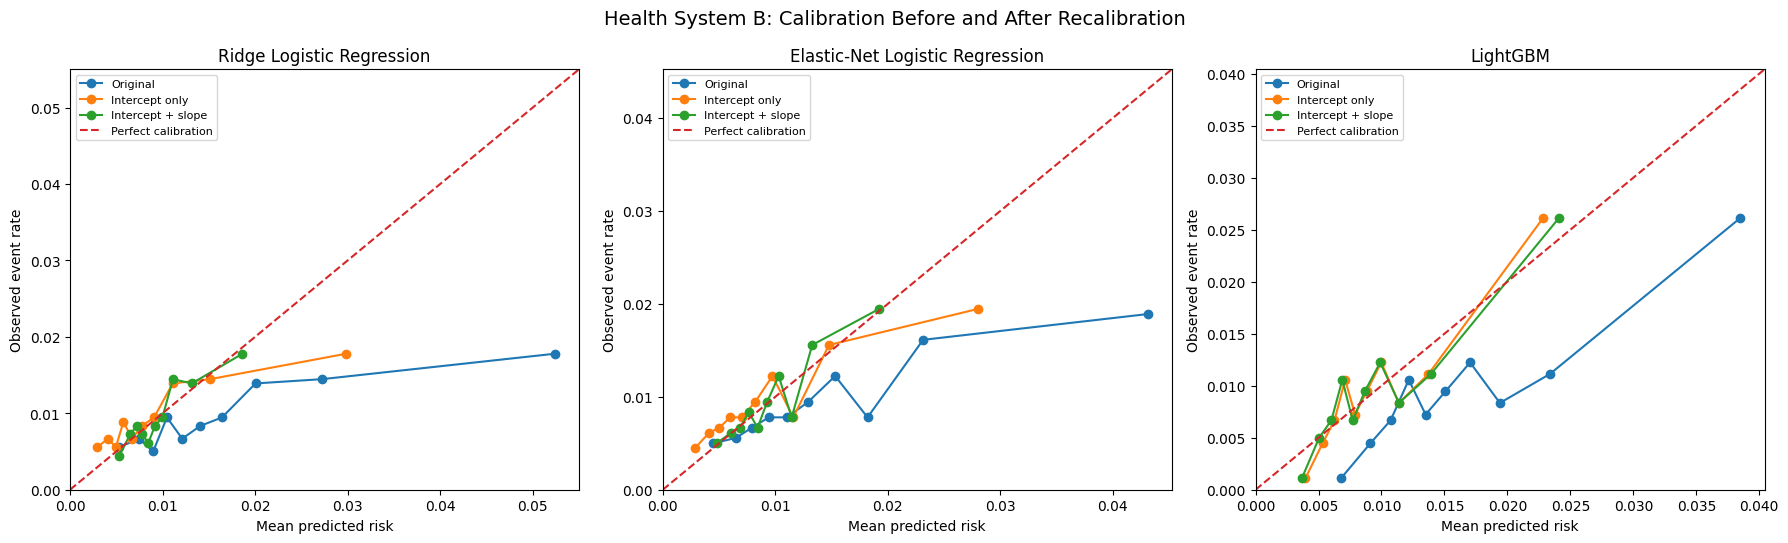

Saved recalibration figure:
figures/system_b_recalibration_calibration_curves.png


In [17]:
FIGURE_DIR = (
    ROOT
    / "figures"
)

FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


RECALIBRATION_FIGURE_PATH = (
    FIGURE_DIR
    / "system_b_recalibration_calibration_curves.png"
)


fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(18, 5.5),
)


for ax, (
    model_name,
    model_key,
) in zip(
    axes,
    model_prediction_keys.items(),
):

    model_tables = (
        calibration_curve_tables[
            model_name
        ]
    )


    for strategy_name in [
        "Original",
        "Intercept only",
        "Intercept + slope",
    ]:

        table = (
            model_tables[
                strategy_name
            ]
        )

        ax.plot(
            table[
                "mean_predicted_risk"
            ],
            table[
                "observed_event_rate"
            ],
            marker="o",
            label=strategy_name,
        )


    max_value = max(
        table[
            "mean_predicted_risk"
        ].max()
        for table in model_tables.values()
    )

    max_value = max(
        max_value,
        max(
            table[
                "observed_event_rate"
            ].max()
            for table in model_tables.values()
        ),
    )


    ax.plot(
        [
            0,
            max_value * 1.05,
        ],
        [
            0,
            max_value * 1.05,
        ],
        linestyle="--",
        label="Perfect calibration",
    )


    ax.set_xlim(
        0,
        max_value * 1.05,
    )

    ax.set_ylim(
        0,
        max_value * 1.05,
    )

    ax.set_title(
        model_name
    )

    ax.set_xlabel(
        "Mean predicted risk"
    )

    ax.set_ylabel(
        "Observed event rate"
    )

    ax.legend(
        fontsize=8
    )


fig.suptitle(
    "Health System B: Calibration Before and After Recalibration",
    fontsize=14,
)

plt.tight_layout()


fig.savefig(
    RECALIBRATION_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)


plt.show()


print(
    f"Saved recalibration figure:\n"
    f"{RECALIBRATION_FIGURE_PATH.relative_to(ROOT)}"
)

## 9. Recalibration Findings

Cross-fitted target-system recalibration substantially improves
probabilistic reliability in Health System B.

All three frozen System A models systematically overpredict risk in
Health System B, as reflected by negative calibration-in-the-large
values before updating.

### Ridge Logistic Regression

Intercept-only updating corrects the overall risk level but leaves a
calibration slope substantially below one.

Allowing both intercept and slope to update provides additional
improvement in Brier score and log loss and restores the calibration
slope to approximately one.

### Elastic-Net Logistic Regression

The same general pattern is observed for elastic-net logistic
regression.

Intercept-only updating corrects baseline-risk miscalibration, while
slope updating provides additional improvement in Brier score.

The incremental log-loss improvement from slope updating is less
certain.

### LightGBM

LightGBM differs from the linear models.

Its original external calibration slope is already close to one, while
its calibration-in-the-large indicates substantial systematic
overprediction.

Intercept-only updating therefore captures essentially all of the
recalibration benefit.

Adding a free calibration slope provides no clear additional improvement
in Brier score or log loss.

### Overall Interpretation

The form of transportability failure is model dependent.

For the linear models, external miscalibration involves both a shift in
baseline risk and excessive dispersion of predicted risks.

For LightGBM, the dominant failure is closer to a baseline-risk shift,
with the relative risk scale largely preserved.

These results show that simple target-system probability updating can
repair substantial external calibration error without refitting the
underlying prediction models.

## 10. Save Recalibration Artifacts

The cross-fitted recalibration results are saved as frozen analysis
artifacts.

Saved outputs include:

- fold-specific recalibration parameters;
- original and cross-fitted recalibrated probabilities;
- recalibration performance summaries;
- paired bootstrap uncertainty estimates;
- direct comparisons of intercept-only versus intercept-and-slope
  updating.

These files preserve the results used for subsequent reporting and
subgroup sensitivity analyses.

In [18]:
TABLE_DIR = (
    ROOT
    / "results"
    / "frozen"
    / "tables"
)

PREDICTION_DIR = (
    ROOT
    / "results"
    / "frozen"
    / "predictions"
)


TABLE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

PREDICTION_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


recalibration_parameters.to_csv(
    TABLE_DIR
    / "system_b_recalibration_parameters.csv",
    index=False,
)


recalibration_performance.to_csv(
    TABLE_DIR
    / "system_b_recalibration_performance.csv",
    index=False,
)


recalibration_delta_summary.to_csv(
    TABLE_DIR
    / "system_b_recalibration_vs_original.csv",
    index=False,
)


recalibration_bootstrap_deltas.to_csv(
    TABLE_DIR
    / "system_b_recalibration_bootstrap_deltas.csv",
    index=False,
)


slope_incremental_value.to_csv(
    TABLE_DIR
    / "system_b_slope_incremental_value.csv",
    index=False,
)


cross_fitted_predictions.to_csv(
    PREDICTION_DIR
    / "system_b_cross_fitted_recalibrated_predictions.csv",
    index=False,
)


print(
    "Saved recalibration tables and "
    "cross-fitted predictions."
)

Saved recalibration tables and cross-fitted predictions.


In [19]:
calibration_curve_records = []


for (
    model_name,
    strategy_tables,
) in calibration_curve_tables.items():

    for (
        strategy_name,
        table,
    ) in strategy_tables.items():

        table_to_save = (
            table
            .copy()
        )

        table_to_save.insert(
            0,
            "strategy",
            strategy_name,
        )

        table_to_save.insert(
            0,
            "model",
            model_name,
        )


        calibration_curve_records.append(
            table_to_save
        )


calibration_curve_summary = pd.concat(
    calibration_curve_records,
    ignore_index=True,
)


calibration_curve_summary.to_csv(
    TABLE_DIR
    / "system_b_recalibration_calibration_curves.csv",
    index=False,
)


calibration_curve_summary.head(15)

,model,strategy,risk_bin,patients,events,mean_predicted_risk,observed_event_rate
0,Ridge Logistic Regression,Original,0,1799,10,0.005300,0.005559
1,Ridge Logistic Regression,Original,1,1798,12,0.007459,0.006674
2,Ridge Logistic Regression,Original,2,1798,9,0.008983,0.005006
3,Ridge Logistic Regression,Original,3,1798,17,0.010469,0.009455
4,Ridge Logistic Regression,Original,4,1798,12,0.012125,0.006674
5,Ridge Logistic Regression,Original,5,1798,15,0.014060,0.008343
6,Ridge Logistic Regression,Original,6,1798,17,0.016415,0.009455
7,Ridge Logistic Regression,Original,7,1798,25,0.020045,0.013904
8,Ridge Logistic Regression,Original,8,1798,26,0.027196,0.014461
9,Ridge Logistic Regression,Original,9,1799,32,0.052375,0.017788


## 11. Frozen Recalibration Summary

A compact summary of the principal recalibration findings is generated
for downstream reporting.

For each model, the table records:

- original external calibration-in-the-large;
- original calibration slope;
- Brier-score improvement from intercept-only updating;
- Brier-score improvement from intercept-and-slope updating;
- incremental Brier-score benefit of adding slope updating.

In [20]:
frozen_recalibration_summary_records = []


for model_name in model_prediction_keys:

    performance = (
        recalibration_performance.loc[
            recalibration_performance[
                "model"
            ] == model_name
        ]
        .set_index(
            "strategy"
        )
    )


    slope_comparison = (
        slope_incremental_value.loc[
            (
                slope_incremental_value[
                    "model"
                ] == model_name
            )
            &
            (
                slope_incremental_value[
                    "metric"
                ] == "delta_Brier"
            )
        ]
        .iloc[0]
    )


    frozen_recalibration_summary_records.append(
        {
            "model":
                model_name,

            "original_CITL":
                float(
                    performance.loc[
                        "Original",
                        "calibration_in_the_large",
                    ]
                ),

            "original_calibration_slope":
                float(
                    performance.loc[
                        "Original",
                        "calibration_slope",
                    ]
                ),

            "intercept_only_delta_Brier":
                float(
                    performance.loc[
                        "Intercept only",
                        "Brier_score",
                    ]
                    -
                    performance.loc[
                        "Original",
                        "Brier_score",
                    ]
                ),

            "intercept_slope_delta_Brier":
                float(
                    performance.loc[
                        "Intercept + slope",
                        "Brier_score",
                    ]
                    -
                    performance.loc[
                        "Original",
                        "Brier_score",
                    ]
                ),

            "slope_incremental_delta_Brier":
                float(
                    slope_comparison[
                        "estimate"
                    ]
                ),

            "slope_incremental_Brier_lower_95_ci":
                float(
                    slope_comparison[
                        "lower_95_ci"
                    ]
                ),

            "slope_incremental_Brier_upper_95_ci":
                float(
                    slope_comparison[
                        "upper_95_ci"
                    ]
                ),
        }
    )


frozen_recalibration_summary = pd.DataFrame(
    frozen_recalibration_summary_records
)


frozen_recalibration_summary.to_csv(
    TABLE_DIR
    / "system_b_recalibration_frozen_summary.csv",
    index=False,
)


frozen_recalibration_summary

,model,original_CITL,original_calibration_slope,intercept_only_delta_Brier,intercept_slope_delta_Brier,slope_incremental_delta_Brier,slope_incremental_Brier_lower_95_ci,slope_incremental_Brier_upper_95_ci
0,Ridge Logistic Regression,-0.599991,0.545522,-0.000196,-0.000257,-0.000061,-0.000104,-0.000022
1,Elastic-Net Logistic Regression,-0.457570,0.616111,-0.000108,-0.000168,-0.000060,-0.000106,-0.000021
2,LightGBM,-0.541716,1.070109,-0.000065,-0.000063,0.000002,-0.000002,0.000006


## 12. Artifact Integrity Check

Before closing the recalibration analysis, the saved patient-level
prediction artifact is checked for completeness and consistency.

No recalibrated probability may be missing or fall outside the valid
probability range.

In [21]:
saved_recalibration_predictions = pd.read_csv(
    PREDICTION_DIR
    / "system_b_cross_fitted_recalibrated_predictions.csv"
)


saved_probability_columns = [
    col
    for col in saved_recalibration_predictions.columns
    if (
        col.endswith(
            "_original"
        )
        or col.endswith(
            "_intercept_only"
        )
        or col.endswith(
            "_intercept_slope"
        )
    )
]


artifact_integrity_summary = pd.Series(
    {
        "patients":
            len(
                saved_recalibration_predictions
            ),

        "positive_events":
            int(
                saved_recalibration_predictions[
                    "outcome"
                ].sum()
            ),

        "duplicate_patient_ids":
            int(
                saved_recalibration_predictions[
                    "patient_id"
                ]
                .duplicated()
                .sum()
            ),

        "probability_columns":
            len(
                saved_probability_columns
            ),

        "missing_probability_values":
            int(
                saved_recalibration_predictions[
                    saved_probability_columns
                ]
                .isna()
                .sum()
                .sum()
            ),

        "probabilities_below_zero":
            int(
                (
                    saved_recalibration_predictions[
                        saved_probability_columns
                    ]
                    < 0
                )
                .sum()
                .sum()
            ),

        "probabilities_above_one":
            int(
                (
                    saved_recalibration_predictions[
                        saved_probability_columns
                    ]
                    > 1
                )
                .sum()
                .sum()
            ),
    },
    name="Recalibration artifact integrity",
)


assert artifact_integrity_summary[
    "patients"
] == 17_982

assert artifact_integrity_summary[
    "positive_events"
] == 175

assert artifact_integrity_summary[
    "duplicate_patient_ids"
] == 0

assert artifact_integrity_summary[
    "probability_columns"
] == 9

assert artifact_integrity_summary[
    "missing_probability_values"
] == 0

assert artifact_integrity_summary[
    "probabilities_below_zero"
] == 0

assert artifact_integrity_summary[
    "probabilities_above_one"
] == 0


artifact_integrity_summary.to_frame()

,Recalibration artifact integrity
patients,17982
positive_events,175
duplicate_patient_ids,0
probability_columns,9
missing_probability_values,0
probabilities_below_zero,0
probabilities_above_one,0


## 13. Final Status

**Health System B recalibration analysis is complete.**

Cross-fitted target-system recalibration demonstrates that the external
calibration failure is substantially repairable without refitting the
underlying System A prediction models.

The principal findings are:

- all three frozen models systematically overpredict absolute risk in
  Health System B;
- intercept-only updating corrects the baseline-risk mismatch for all
  three models;
- Ridge and elastic-net logistic regression retain calibration slopes
  substantially below one after intercept-only updating and benefit
  from additional slope correction;
- LightGBM retains a calibration slope close to one during external
  transport and obtains essentially all probabilistic-performance
  improvement from intercept-only updating;
- paired bootstrap analyses support consistent improvements in Brier
  score and log loss after recalibration;
- adding slope updating provides clear additional Brier-score benefit
  for the linear models but no clear benefit for LightGBM.

These findings indicate that transportability failure is not uniform
across model classes.

For the linear models, cross-system miscalibration involves both
baseline-risk shift and distortion of the predicted-risk scale.

For LightGBM, the dominant transportability failure is consistent with
a change in baseline risk while relative-risk scaling is comparatively
well preserved.

The frozen external-validation results remain unchanged; recalibration
is treated as a separate target-system model-updating analysis.